# L'anomalie overnight — analyse quantitative
### Données réelles, démontage critique, statistiques, réalisme d'exécution

Version rigoureuse du [notebook pour curieux](01_pour_les_curieux.ipynb). On y traite quatre questions qu'un quant sceptique pose immédiatement :

1. **Le motif tient-il sur données réelles, partout ?** (spoiler : non — et c'est instructif)
2. **Le Sharpe overnight est-il distinguable de zéro ? Est-ce de l'alpha ou du bêta déguisé ?**
3. **Survit-il aux coûts d'exécution réels ?**
4. **Le tout est-il reproductible ?**

> ⚠️ **Pas un conseil en investissement.** Données : Yahoo! Finance via `yfinance`, mode d'ajustement `split_only` (choix documenté en §3.3). Première exécution = accès réseau.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

from overnight import data, decompose, diagnostics, backtest, stats


## 1. Le motif sur 10 indices mondiaux (ETF)

On décompose chaque ETF en nuit / jour et on lit le Sharpe **annualisé de la jambe overnight** — le seul chiffre qui compte pour juger d'un *edge*.

In [2]:
rows, decs = {}, {}
for tk, label in data.WORLD_INDICES.items():
    try:
        dec = decompose.decompose(data.fetch(tk, mode='split_only'))
    except Exception as e:
        print(f'{tk}: FAILED {e}'); continue
    decs[tk] = dec
    s = decompose.summary(dec)
    rows[tk] = {
        'pays': label,
        'nuit cum %': s.loc['overnight','cum_return']*100,
        'jour cum %': s.loc['intraday','cum_return']*100,
        'Sharpe nuit': s.loc['overnight','sharpe'],
        'Sharpe jour': s.loc['intraday','sharpe'],
        'jours suspects': len(diagnostics.flag_suspicious_returns(dec)),
    }
table = pd.DataFrame(rows).T
table

,pays,nuit cum %,jour cum %,Sharpe nuit,Sharpe jour,jours suspects
SPY,USA (S&P 500 ETF),"1,168.799",32.301,0.772,0.131,0
QQQ,USA (Nasdaq-100 ETF),"5,415.485",-49.931,0.706,0.005,1
EWU,UK (MSCI UK ETF),-84.812,516.902,-0.196,0.465,1
EWG,Germany (MSCI Germany ETF),-64.165,774.509,-0.068,0.511,0
EWQ,France (MSCI France ETF),-49.385,602.881,-0.019,0.493,0
EWJ,Japan (MSCI Japan ETF),-91.473,341.472,-0.190,0.443,1
EWH,Hong Kong (MSCI HK ETF),320.559,-60.281,0.324,-0.082,0
EWZ,Brazil (MSCI Brazil ETF),"4,680.213",-96.231,0.696,-0.335,0
INDA,India (MSCI India ETF),233.728,-46.912,0.550,-0.340,0
FXI,China (large-cap ETF),244.453,69.206,0.263,0.224,1


Lecture rapide : **USA (SPY, QQQ)** et **Brésil** affichent le motif classique (nuit énorme, jour faible ou négatif, Sharpe nuit ~0,7). Mais regardez l'**Europe (UK, Allemagne, France)** et le **Japon** : le motif est **inversé**. Ce n'est pas un détail — c'est le cœur du démontage.

## 2. Démontage critique

### 2.1 L'inversion des ETF étrangers : on mesure le fuseau horaire, pas une anomalie

Visualisons le Sharpe nuit vs jour par marché :

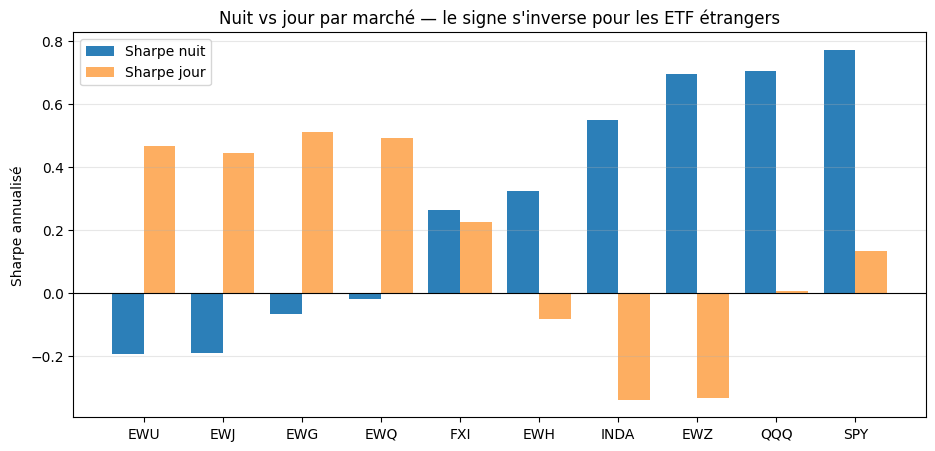

In [3]:
t = table.sort_values('Sharpe nuit')
x = np.arange(len(t)); w = 0.4
fig, ax = plt.subplots(figsize=(11,5))
ax.bar(x-w/2, t['Sharpe nuit'].astype(float), w, label='Sharpe nuit', color='#2c7fb8')
ax.bar(x+w/2, t['Sharpe jour'].astype(float), w, label='Sharpe jour', color='#fdae61')
ax.axhline(0, color='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(t.index)
ax.set_ylabel('Sharpe annualisé'); ax.set_title('Nuit vs jour par marché — le signe s\'inverse pour les ETF étrangers')
ax.legend(); ax.grid(axis='y', alpha=.3); plt.show()

**Explication microstructure.** EWU, EWG, EWQ, EWJ sont des ETF cotés à New York mais dont le sous-jacent (Londres, Francfort, Paris, Tokyo) **trade pendant la nuit américaine**. Pour ces produits, la fenêtre « overnight » (horloge US, clôture→ouverture) **contient la séance du marché domestique**, tandis que la fenêtre « intraday » US correspond aux heures où le sous-jacent est largement fermé (le prix ne bouge que par arbitrage sur le NAV).

Autrement dit : **la décomposition nuit/jour est relative à l'horloge de cotation**. Appliquée à un instrument décalé de son marché, elle mesure surtout le fuseau horaire — pas une « anomalie ». Un manipulateur mondial unique expliquerait mal pourquoi le signe dépend du lieu de cotation de l'ETF. C'est un argument de prudence majeur, et un rappel : **toujours vérifier ce que la fenêtre temporelle capture réellement pour l'instrument choisi.**

### 2.2 Le test de la Chine et la règle T+1

Sur les actions chinoises, la littérature (Qiao & Dam, 2020) documente un motif **inversé** (jour positif, nuit négative), proprement expliqué par la règle **T+1** (titres achetés un jour invendables avant le lendemain). Notre proxy ETF (FXI, coté US) ne teste pas directement les A-shares, mais on note un signal nettement plus faible que pour les USA :

In [4]:
if 'FXI' in decs:
    s = decompose.summary(decs['FXI'])
    print('Chine (FXI) — Sharpe nuit : {:+.2f}  vs  USA (SPY) : {:+.2f}'.format(
        s.loc['overnight','sharpe'], decompose.summary(decs['SPY']).loc['overnight','sharpe']))
    print('Un motif universel et orchestré devrait être plus homogène géographiquement.')

Chine (FXI) — Sharpe nuit : +0.26  vs  USA (SPY) : +0.77
Un motif universel et orchestré devrait être plus homogène géographiquement.


### 2.3 Composition et sélection

Comme montré dans le notebook pour curieux, les magnitudes en log sont dominées par la **composition** (un biais de 1 pdb → +124 % sur 32 ans) et par la **sélection** (les figures les plus spectaculaires sont, de l'aveu même de l'auteur, « les 25 plus problématiques »). Le **compteur de jours suspects** (colonne de §1) reste faible ici car les ETF US sont propres — les artefacts vivent surtout dans les **indices spot émergents bruts** (ex. `^BSESN`), non dans ces ETF. Caveat à garder pour toute reproduction de la fameuse Figure 8 (Inde).

## 3. Rigueur statistique & risque

### 3.1 Le Sharpe overnight est-il distinguable de zéro ? (bootstrap)

Un Sharpe de 0,77 sur un échantillon fini peut-il être du bruit ? Intervalle de confiance à 95 % par bootstrap (2000 rééchantillonnages) :

In [5]:
for tk in ['SPY','QQQ','EWZ','FXI']:
    if tk not in decs: continue
    r = stats.sharpe_ci_bootstrap(decs[tk]['r_overnight'], n_boot=2000, seed=0)
    print(f"{tk:4s} Sharpe nuit = {r['sharpe']:+.2f}  "
          f"IC95% [{r['ci_low']:+.2f}, {r['ci_high']:+.2f}]  "
          f"P(Sharpe<0) = {r['frac_negative']:.1%}  (n={r['n_obs']})")

SPY  Sharpe nuit = +0.77  IC95% [+0.43, +1.12]  P(Sharpe<0) = 0.0%  (n=8394)


QQQ  Sharpe nuit = +0.71  IC95% [+0.50, +1.24]  P(Sharpe<0) = 0.0%  (n=6852)


EWZ  Sharpe nuit = +0.70  IC95% [+0.29, +1.12]  P(Sharpe<0) = 0.0%  (n=6511)


FXI  Sharpe nuit = +0.26  IC95% [-0.17, +0.52]  P(Sharpe<0) = 9.3%  (n=5448)


Pour SPY/QQQ/Brésil l'intervalle exclut largement zéro : l'effet est **statistiquement réel**. La question n'est donc pas *« existe-t-il ? »* mais *« est-ce de l'alpha exploitable ? »* — d'où les deux sections suivantes.

### 3.2 Alpha, ou bêta déguisé ?

Détenir le marché *chaque nuit*, c'est porter le **risque de gap** en permanence. Une partie de « l'alpha overnight » est donc une **prime de risque de bêta**, pas un edge distinct. On régresse la jambe nuit sur le marché (close-close) : `r_nuit = α + β·r_marché + ε`.

In [6]:
d = stats.beta_decomposition(decs['SPY'], leg='overnight')
print('SPY — jambe overnight régressée sur le marché (close-close) :')
print(f"  bêta = {d['beta']:.2f}   R² = {d['r_squared']:.2f}")
print(f"  rendement nuit moyen = {d['mean_leg_bps']:.2f} pdb/jour")
print(f"     dont bêta×marché  = {d['beta_contrib_bps']:.2f} pdb   (prime de risque)")
print(f"     dont alpha résid. = {d['alpha_daily_bps']:.2f} pdb   ({d['alpha_ann_pct']:+.1f}%/an)")

SPY — jambe overnight régressée sur le marché (close-close) :
  bêta = 0.33   R² = 0.33
  rendement nuit moyen = 3.25 pdb/jour
     dont bêta×marché  = 1.33 pdb   (prime de risque)
     dont alpha résid. = 1.92 pdb   (+5.0%/an)


Deux lectures, toutes deux défavorables à la thèse de l'edge facile :

- **~40 % du rendement nocturne est du bêta** (bêta ≈ 0,33 sur SPY) : détenir le marché la nuit est en partie une simple **prime de risque de gap**, pas un alpha distinct.
- Surtout, l'**alpha résiduel (~1,9 pdb/jour) est *inférieur* au coût de point mort (~3,25 pdb)** calculé en §4 : même la part « non-bêta » du rendement ne survit pas aux frais d'exécution. C'est le clou du cercueil — il faut facturer les coûts sur l'alpha, pas sur le rendement brut.

### 3.3 Sensibilité au mode d'ajustement des dividendes

Le mode d'ajustement n'est **pas un détail** : un titre passe ex-dividende à l'**ouverture**, donc l'ajustement déplace du rendement entre nuit et jour. Comparons `split_only` (défaut, garde le gap ex-div dans la nuit) vs `total_return` (tout ajusté) sur SPY :

In [7]:
spy_tr = decompose.decompose(data.fetch('SPY', mode='total_return'))
spy_so = decs['SPY']
print('SPY — nuit cumulée :')
print(f"  split_only   : {spy_so['cum_overnight'].iloc[-1]*100:+,.0f}%")
print(f"  total_return : {spy_tr['cum_overnight'].iloc[-1]*100:+,.0f}%")
print('Le choix déplace le niveau de la jambe nuit -> à documenter dans toute figure publiée.')

SPY — nuit cumulée :
  split_only   : +1,169%
  total_return : +2,206%
Le choix déplace le niveau de la jambe nuit -> à documenter dans toute figure publiée.


## 4. Réalisme d'exécution

Modèle de coût par nuit détenue :
`coût = 2×(½·spread + commission + slippage) + financement`. Le **facteur 2** (on traverse la fourchette à l'achat *et* à la vente, ~252×/an) est le tueur. Point mort et balayage sur SPY :

In [8]:
be = backtest.breakeven_cost_bps(spy_so)
print(f'Coût aller-retour de point mort = {be:.2f} pdb/nuit')
sweep = backtest.cost_sweep(spy_so, roundtrip_bps=(0,1,2,3,5,8))
sweep.round(3)

Coût aller-retour de point mort = 3.25 pdb/nuit


,cagr_net,sharpe_net,max_drawdown
roundtrip_bps,,,
0,0.079,0.772,-0.348
1,0.052,0.535,-0.378
2,0.026,0.297,-0.496
3,0.001,0.060,-0.687
5,-0.049,-0.415,-0.890
8,-0.118,-1.127,-0.985


L'edge brut survit à quelques points de base seulement. Trois facteurs aggravants côté retail, non capturés par ce backtest *optimiste* :

- **Prix d'exécution ≠ prints académiques** : l'anomalie est mesurée sur les enchères de clôture/ouverture, inaccessibles au particulier ; à T±5 min on est en séance continue, avec un spread plus large.
- **Swap CFD / MT5** : le financement overnight prélevé chaque nuit peut annuler l'edge à lui seul (vérifier `swap_long` avant tout trade — c'est exactement le garde-fou implémenté dans le connecteur MT5 du repo).
- **Capacité / slippage** : l'impact marché croît avec la taille d'ordre, surtout sur les enchères peu liquides.

## 5. Reproductibilité

- **Déterminisme** : tout le synthétique et le bootstrap sont *seedés*.
- **Tests** : `pytest` vérifie l'identité de décomposition `(1+r_nuit)(1+r_jour)=(1+r_cc)` (erreur ~1e-16) et la monotonie du coût.
- **CI** : GitHub Actions rejoue tests + démo offline sur Python 3.10–3.12.
- **Données** : cache parquet local (`_cache/`), mode d'ajustement explicite.
- **Notebooks générés** : `python notebooks/build_notebooks.py` puis `nbconvert --execute` — la figure que vous lisez est l'output exécuté, pas une capture.

## 6. Verdict honnête

Trois niveaux à ne **jamais** confondre :

1. **Le fait empirique est RÉEL** et bien documenté (Lou-Polk-Skouras 2019, Cooper-Cliff-Gulen 2008, Fed NY). Mérite à Knuteson d'avoir publié données et code.
2. **Les magnitudes sont GONFLÉES** — composition sur 30 ans + échelle log, artefacts de données, biais de sélection/survie.
3. **L'attribution à une fraude orchestrée n'est PAS prouvée** — l'inversion des ETF étrangers (fuseau horaire) et le cas chinois (T+1) favorisent des explications **microstructurelles**, et la majeure partie du « rendement nuit » est du **bêta de gap**, pas un alpha.

Et même en supposant l'edge réel : **il ne survit pas aux coûts d'exécution réels** — comme l'ont montré la liquidation des ETF NSPY / NIWM en 2023. Belle anomalie pour comprendre la microstructure ; piètre stratégie de trading retail.